In [1]:
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df = pd.read_csv("Ice Cream.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 7.9 KB


In [4]:
df.corr()

,Temperature,Revenue
Temperature,1.000000,0.989841
Revenue,0.989841,1.000000


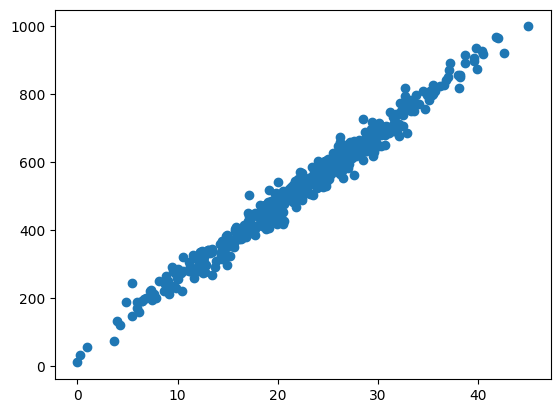

In [5]:
plt.scatter(df["Temperature"],df["Revenue"])

* The feature and target column are higly correlated so the data is linear

In [6]:
X = df[["Temperature"]]
y = df["Revenue"]

In [7]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y, train_size=0.8, random_state=42)

In [8]:
model = LinearRegression()

In [9]:
model.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_train_pred = model.predict(xtrain)

In [11]:
y_test_pred = model.predict(xtest)

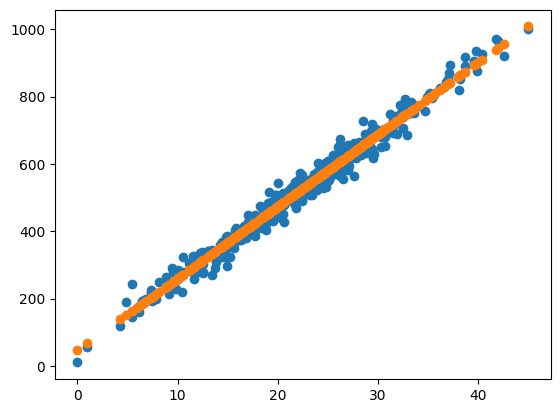

In [12]:
plt.scatter(xtrain,ytrain)
plt.scatter(xtrain,y_train_pred)

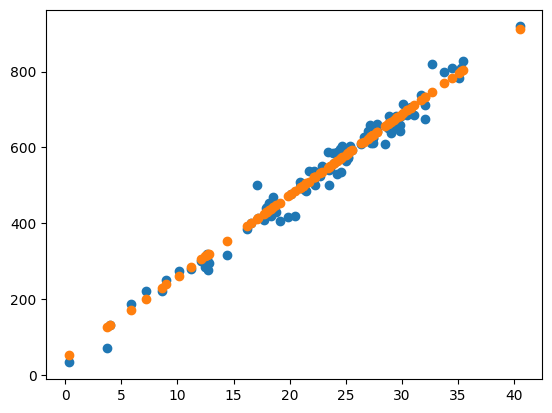

In [13]:
plt.scatter(xtest,ytest)
plt.scatter(xtest,y_test_pred)

In [14]:
r2_train = r2_score(ytrain, y_train_pred)
r2_train

0.9803485203843681

In [15]:
r2_test = r2_score(ytest, y_test_pred)
r2_test

0.9771509516333023

* Both train and test data score are high so the model is good fit.